Paper link: https://arxiv.org/pdf/1512.03385

# How do we fix vanishing gradients in deep NN's?
- introduce residual pathway

# How do we make training affordable?
- introduce bottleneck blocks (1x1 layers reduce and then restore dimensions)




In [9]:
import torch
from torch.utils.data import DataLoader
from torch import nn
from collections import OrderedDict
from torchvision import transforms, datasets
from torch.utils.data import Subset
import matplotlib.pyplot as plt


class Block(nn.Module):
    def __init__(self, in_channels, num_filters, stride=1):
        super().__init__()
        self.layers = nn.Sequential(OrderedDict([
            ('bn1_1', nn.BatchNorm2d(in_channels)),
            ('relu1_1', nn.ReLU()),
            ('conv1_1', nn.Conv2d(in_channels, num_filters, kernel_size=(3, 3), stride=stride, padding=1)),
            ('bn1_2', nn.BatchNorm2d(num_filters)),
            ('conv1_2',  nn.Conv2d(num_filters, num_filters, kernel_size=(3, 3), padding=1)),
        ]))
        self.last_relu = nn.ReLU()
        if stride != 1 or in_channels != num_filters:
            self.shortcut = nn.Sequential(OrderedDict([
                ('sho_conv_1', nn.Conv2d(in_channels, num_filters, kernel_size=(1, 1), stride=stride)),
                ('sho_bn1', nn.BatchNorm2d(num_filters))
            ]))
        else:
            self.shortcut = nn.Identity()
    
    def forward(self, x):
        x = self.layers(x) + self.shortcut(x)
        x = self.last_relu(x)
        return x

class ResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(OrderedDict([
            ('conv1_1', nn.Conv2d(3, 64, kernel_size=(3, 3), stride=2)),
            ('bn1_1', nn.BatchNorm2d(64)),
            ('relu1_1', nn.ReLU()),
            ('block1', Block(in_channels=64, num_filters=64)),
            ('block2', Block(in_channels=64, num_filters=64)),
            ('block3', Block(in_channels=64, num_filters=128, stride=2)),
            ('block4', Block(in_channels=128, num_filters=128)),
            ('block5', Block(in_channels=128, num_filters=256, stride=2)),
            ('block6', Block(in_channels=256, num_filters=256)),
            ('block7', Block(in_channels=256, num_filters=512, stride=2)),
            ('block8', Block(in_channels=512, num_filters=512)),
        ]))
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.linear = nn.Linear(512, 100)
    
    def forward(self, x):
        x = self.layers(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.linear(x)
        return x

In [10]:
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.cuda.empty_cache()

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Mild to avoid over-distortion
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4865, 0.4409], std=[0.2673, 0.2564, 0.2761]),
    transforms.RandomErasing(p=0.25)  # Apply after normalization for consistency
])

test_transform = transforms.Compose([
    transforms.ToTensor(), # Moved ToTensor before Normalize (good practice)
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
])

# Load raw datasets
cifar_train_raw = datasets.CIFAR100(root="./data", train=True, download=True, transform=None)

train_size = int(0.9 * len(cifar_train_raw))  # 48,000

train_indices = list(range(0, train_size))
val_indices = list(range(train_size, len(cifar_train_raw)))

# Create datasets with appropriate transforms
cifar_train = Subset(
    datasets.CIFAR100(root="./data", train=True, transform=train_transform),
    train_indices
)
cifar_val = Subset(
    datasets.CIFAR100(root="./data", train=True, transform=test_transform),
    val_indices
)
# Use original test set (10,000 samples) - close to 10% of 60,000
cifar_test = datasets.CIFAR100(root="./data", train=False, transform=test_transform)

train_loader = DataLoader(
    cifar_train,
    batch_size=256,  # Changed from 512
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=6
)

val_loader = DataLoader(
    cifar_val,  # Use directly
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=6
)

test_loader = DataLoader(
    cifar_test,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=6
)

num_classes = 100

model = ResNet18().to(device)

num_epochs = 40
loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)

'''
Our training used asynchronous stochastic gradient descent with 0.9 momentum [17], 
fixed learning rate schedule (decreasing the learning rate by 4% every 8 epochs). 
'''

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,  # Changed from 1e-3
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-2,  # Changed from 3e-3
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25.0,
    final_div_factor=1000.0
)

train_losses = []
val_losses = []
epochs_recorded = []

best_val_loss = float('inf')

for epoch in range(num_epochs):
    print(f'Starting Epoch {epoch+1}')
    model.train()

    current_loss = 0.0
    num_batches = 0

    for i, data in enumerate(train_loader):
        inputs, targets = data
        inputs, targets = inputs.to(device), targets.to(device)
            
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()

        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()  # Step per batch for OneCycleLR

        current_loss += loss.item()
        num_batches += 1

        if i % 50 == 0:
            torch.cuda.empty_cache()
            print(f'Batch {i}/{len(train_loader)}, Loss: {loss.item():.4f}')

    avg_train_loss = current_loss / num_batches

    # Validate EVERY epoch (removed the if condition)
    model.eval()
    val_loss = 0.0
    val_batches = 0

    with torch.no_grad():
        for val_data in val_loader:
            val_inputs, val_targets = val_data
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)

            val_outputs = model(val_inputs)
            val_batch_loss = loss_function(val_outputs, val_targets)

            val_loss += val_batch_loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    best_val_loss = min(best_val_loss, avg_val_loss)

    # Record metrics every epoch
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    epochs_recorded.append(epoch + 1)

    print(f'Epoch {epoch+1} - Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')

if torch.cuda.is_available():
    torch.cuda.empty_cache()



Using device: cuda
GPU Memory: 15.8 GB
Starting Epoch 1
Batch 0/176, Loss: 4.7728
Batch 50/176, Loss: 4.2257
Batch 100/176, Loss: 4.0911
Batch 150/176, Loss: 4.0457
Epoch 1 - Training Loss: 4.2085, Validation Loss: 3.7802
Starting Epoch 2
Batch 0/176, Loss: 3.9366
Batch 50/176, Loss: 3.7379
Batch 100/176, Loss: 3.7240
Batch 150/176, Loss: 3.7307
Epoch 2 - Training Loss: 3.8647, Validation Loss: 3.7251
Starting Epoch 3
Batch 0/176, Loss: 3.6869
Batch 50/176, Loss: 3.7535
Batch 100/176, Loss: 3.7130
Batch 150/176, Loss: 3.6890
Epoch 3 - Training Loss: 3.7199, Validation Loss: 3.4866
Starting Epoch 4
Batch 0/176, Loss: 3.6228
Batch 50/176, Loss: 3.5087
Batch 100/176, Loss: 3.5422
Batch 150/176, Loss: 3.4239
Epoch 4 - Training Loss: 3.5937, Validation Loss: 3.4505
Starting Epoch 5
Batch 0/176, Loss: 3.6540
Batch 50/176, Loss: 3.5958
Batch 100/176, Loss: 3.3982
Batch 150/176, Loss: 3.5184
Epoch 5 - Training Loss: 3.4737, Validation Loss: 3.2180
Starting Epoch 6
Batch 0/176, Loss: 3.4227
Bat

In [11]:
def evaluate_test_set(model):
    model.eval()
    correct = 0
    total = 0
    
    print("Starting evaluation...")
    
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            
            # Use autocast for consistency if you trained with it
            outputs = model(images)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f}%')
    return accuracy

print("\n=== Running standard evaluation ===")
standard_accuracy = evaluate_test_set(model)   
print(f'Standard Test Accuracy: {standard_accuracy:.4f} ({standard_accuracy*100:.2f}%)')


=== Running standard evaluation ===
Starting evaluation...
Accuracy of the network on the test images: 62.67%
Standard Test Accuracy: 62.6700 (6267.00%)


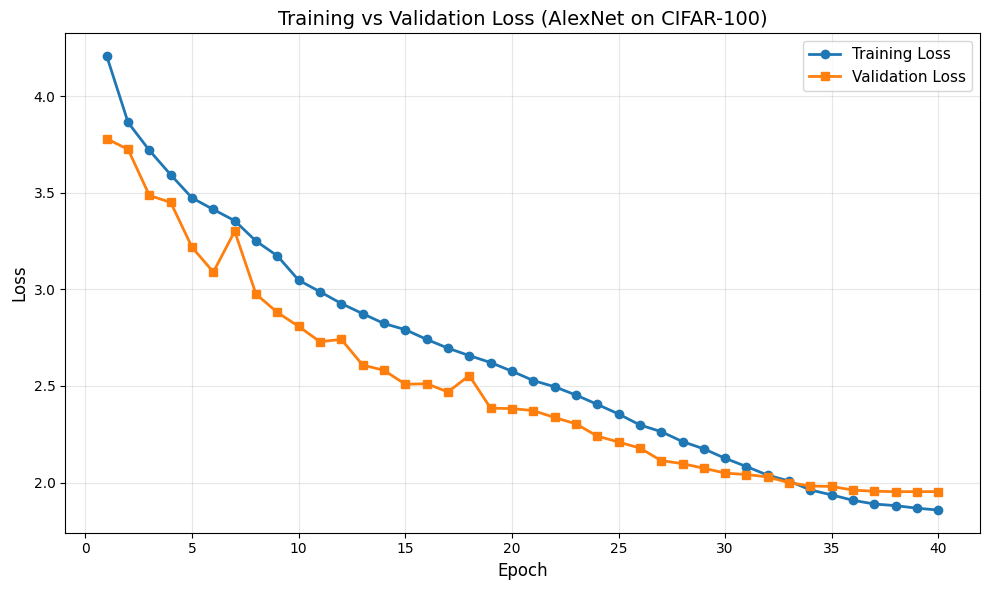


Final training loss: 1.8577
Final validation loss: 1.9531
Gap (val - train): 0.0954
✓ Model shows good generalization (small gap)


In [12]:

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs_recorded, train_losses, label='Training Loss', linewidth=2, marker='o')
plt.plot(epochs_recorded, val_losses, label='Validation Loss', linewidth=2, marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training vs Validation Loss (AlexNet on CIFAR-100)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('alexnet_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Print final gap analysis
final_gap = val_losses[-1] - train_losses[-1]
print(f"\nFinal training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")
print(f"Gap (val - train): {final_gap:.4f}")

if final_gap < 0.1:
    print("✓ Model shows good generalization (small gap)")
elif final_gap < 0.3:
    print("⚠ Mild overfitting detected")
else:
    print("✗ Significant overfitting detected")